In [60]:
import shap
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
shap.initjs()

In [67]:
# Dữ liệu giả lập
df = pd.DataFrame({
    "Age": [25, 45, 65, 80, 50, 85],
    "HeartRate": [70, 85, 100, 120, 90, 130],
    "Death": [0, 0, 1, 1, 0, 1]   # 1 = chết, 0 = sống
})

X = df[["Age", "HeartRate"]]
y = df["Death"]

# Huấn luyện mô hình logistic
model = LogisticRegression().fit(X, y)
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

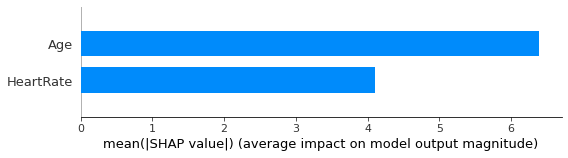

In [68]:
shap.summary_plot(shap_values, plot_type='bar')

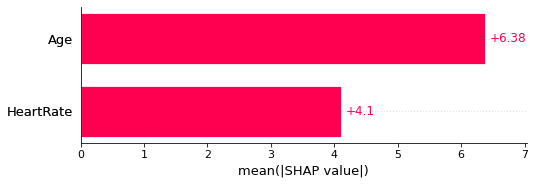

In [40]:
shap.plots.bar(shap_values)

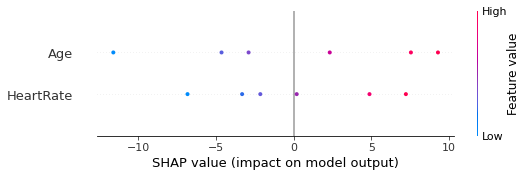

In [41]:
shap.plots.beeswarm(shap_values)

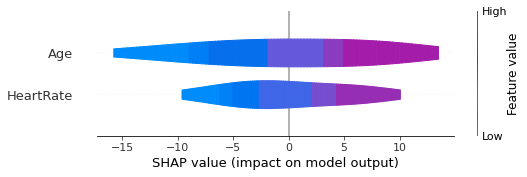

In [42]:
shap.plots.violin(shap_values)

In [15]:
help(shap.plots.decision)

Help on function decision in module shap.plots._decision:

decision(base_value: 'float | np.ndarray', shap_values: 'np.ndarray', features: 'np.ndarray | pd.Series | pd.DataFrame | list | None' = None, feature_names=None, feature_order='importance', feature_display_range=None, highlight=None, link='identity', plot_color=None, axis_color='#333333', y_demarc_color='#333333', alpha=None, color_bar=True, auto_size_plot=True, title=None, xlim=None, show=True, return_objects=False, ignore_warnings=False, new_base_value=None, legend_labels=None, legend_location='best') -> 'DecisionPlotResult | None'
    Visualize model decisions using cumulative SHAP values.

    Each plotted line explains a single model prediction. If a single prediction is plotted, feature values will be
    printed in the plot (if supplied). If multiple predictions are plotted together, feature values will not be printed.
    Plotting too many predictions together will make the plot unintelligible.

    Parameters
    -----

In [18]:
shap_values.base_values[0]

-2.0641001042577756

In [19]:
shap_values[0]

.values =
array([-9.7563251 , -5.38830539])

.base_values =
-2.0641001042577756

.data =
array([25, 70], dtype=int64)

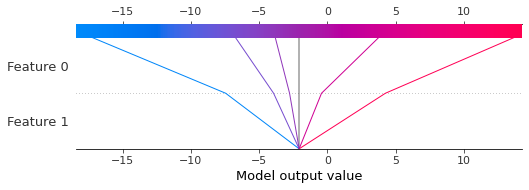

In [24]:
shap.plots.decision(shap_values.base_values[0], shap_values = shap_values.values)

In [43]:
help(shap.plots.group_difference)

Help on function group_difference in module shap.plots._group_difference:

group_difference(shap_values, group_mask, feature_names=None, xlabel=None, xmin=None, xmax=None, max_display=None, sort=True, show=True, ax=None)
    This plots the difference in mean SHAP values between two groups.

    It is useful to decompose many group level metrics about the model output among the
    input features. Quantitative fairness metrics for machine learning models are
    a common example of such group level metrics.

    Parameters
    ----------
    shap_values : numpy.array
        Matrix of SHAP values (# samples x # features) or a vector of model outputs (# samples).

    group_mask : numpy.array
        A boolean mask where True represents the first group of samples and False the second.

    feature_names : list
        A list of feature names.



In [55]:
masked = df['Death'] == 1
masked = masked.values

In [56]:
shap_values.values[masked].mean(axis = 0)- shap_values.values[~masked].mean(axis = 0)

array([12.76675483,  8.19699685])

c:\Users\npchi\.conda\envs\tktmdt\Lib\site-packages\shap\plots\_group_difference.py:42: RuntimeWarning: Mean of empty slice.
  vs.append(shap_values[r].mean(0) - shap_values[~r].mean(0))
c:\Users\npchi\.conda\envs\tktmdt\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


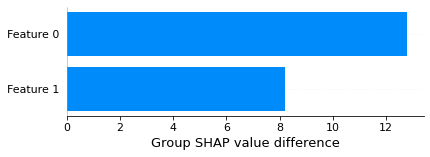

In [57]:
shap.plots.group_difference(shap_values = shap_values.values, group_mask = masked)

In [47]:
import numpy as np
np.abs(shap_values.values).mean(axis = 0)

array([6.38337741, 4.09849842])

In [46]:
model.coef_, model.intercept_

(array([[0.34818422, 0.23419991]]), array([-42.29697154]))

In [30]:
X.mean(axis=0)

Age          53.0
HeartRate    93.0
dtype: float64

In [21]:
X.mean(axis=0).values @ model.coef_.T + model.intercept_

array([-2.0641001])

In [7]:
import math

In [17]:
math.log(model.predict_proba(X)[:, 1].mean())

-0.9162911042202773

In [29]:
#math.log(0.4/ 0.6), math.log2(0.4 / 0.6), math.log10(0.4 / 0.6)

In [34]:
(X - X.mean()).values * model.coef_

array([[-9.7563251 , -5.38830539],
       [-2.78752146, -1.87419318],
       [ 4.18128219,  1.63991903],
       [ 9.40788492,  6.32540198],
       [-1.04532055, -0.70282244]])

In [44]:
model.predict_proba(X)

array([[9.99999966e-01, 3.36003071e-08],
       [9.98801894e-01, 1.19810569e-03],
       [2.28184929e-02, 9.77181507e-01],
       [1.15756957e-06, 9.99998842e-01],
       [9.78379233e-01, 2.16207665e-02]])

In [43]:
import numpy as np
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

sigmoid(shap_values.values.sum(axis=1) + shap_values.base_values)


array([3.36003071e-08, 1.19810569e-03, 9.77181507e-01, 9.99998842e-01,
       2.16207665e-02])

In [39]:
shap_values.base_values

array([-2.0641001, -2.0641001, -2.0641001, -2.0641001, -2.0641001])

In [4]:
sample = X.iloc[[2]]   # bệnh nhân 3: Age=65, HeartRate=100
shap_value = explainer(sample)

print(shap_value.values)

[[4.18128219 1.63991903]]


In [27]:
#help(shap.summary_plot)

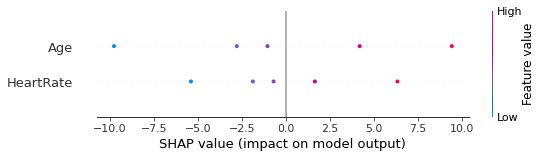

In [28]:
plt.rcParams['figure.figsize'] = (20, 10)
shap.summary_plot(shap_values, show = False)
plt.show()


In [71]:
np.sum(shap_values.values[0] - shap_values.base_values[0])


-20.914169819887903

In [70]:
shap_values[0]

.values =
array([-11.60614075,  -6.83083071])

.base_values =
1.2385991803655045

.data =
array([25, 70], dtype=int64)

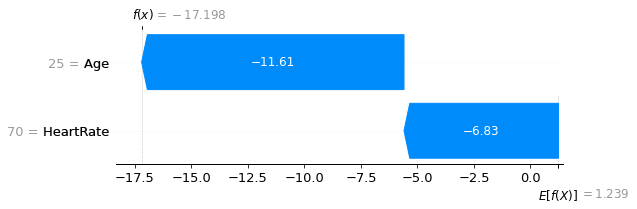

In [64]:
shap.plots.waterfall(shap_values[0])


In [72]:
shap.plots.force(shap_values[0])